In [12]:
# set up the python
from dask.distributed import Client
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import numpy as np
import xarray as xr
import cmocean as cm
import cartopy.crs as ccrs
import cmocean as cm
import cartopy.feature as cft
import cftime
import IPython.display
import sys, os, warnings
import matplotlib.animation as animation
from cartopy.mpl.geoaxes import GeoAxes  # Import GeoAxes for Cartopy plotting
from mpl_toolkits.axes_grid1 import AxesGrid
import gsw
from xhistogram.xarray import histogram as xhistogram
from xgcm import Grid
import intake

In [13]:
client = Client(n_workers=28)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45799 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/45799/status,
Dashboard: /proxy/45799/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35397,Workers: 0
Dashboard: /proxy/45799/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41669,Total threads: 1
Dashboard: /proxy/46719/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:38125,


In [14]:
new_coord = xr.open_dataarray('/scratch/x77/hm1221/nc_files/lat_to_shelf_bin.nc')

In [15]:
bound_AAIW = xr.open_dataarray('/g/data/x77/hm1221/PhD_P1_data/rho_ctrl.nc')

In [16]:
# time period
start_time = '2140-01-01'
end_time = '2164-12-31'

In [17]:
# time period for map
start_time1 = '2160-01-01'
end_time1 = '2164-12-31'

start_time2 = '2151-12-01'
end_time2 = '2154-12-31'


In [18]:
# time period
start_time3 = '2150-01-01'
end_time3 = '2164-12-31'

In [19]:
expt_datastore = intake.open_esm_datastore(
    "./ssp585_th.json", 
    columns_with_iterables=[
            "variable",
            "variable_long_name",
            "variable_standard_name",
            "variable_cell_methods",
            "variable_units",
    ] # This is important
)


In [20]:
expt_datastore_1 = intake.open_esm_datastore(
    "./windthermal.json", 
    columns_with_iterables=[
            "variable",
            "variable_long_name",
            "variable_standard_name",
            "variable_cell_methods",
            "variable_units",
    ] # This is important
)


In [21]:
catalog = intake.cat.access_nri

In [22]:
# read practical salinity
temp_th = expt_datastore.search(variable="temp",frequency = '1mon').to_dask()
temp_th = temp_th.temp.sel(time = slice(start_time, end_time))

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [23]:
# read practical salinity
salt_th = expt_datastore.search(variable="salt",frequency = '1mon').to_dask()
salt_th = salt_th.salt.sel(time = slice(start_time, end_time))

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [24]:
# read practical salinity
temp_wt = expt_datastore_1.search(variable="temp",frequency = '1mon').to_dask()
temp_wt = temp_wt.temp.sel(time = slice(start_time, end_time))

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [25]:
# read practical salinity
salt_wt = expt_datastore.search(variable="salt",frequency = '1mon').to_dask()
salt_wt = salt_wt.salt.sel(time = slice(start_time, end_time))

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [26]:
temp_ctrl = catalog['01deg_jra55v13_ryf9091'].search(variable="temp",frequency = '1mon').to_dask()
temp_ctrl = temp_ctrl.temp.sel(time = slice(start_time, end_time))

In [27]:
salt_ctrl = catalog['01deg_jra55v13_ryf9091'].search(variable="salt",frequency = '1mon').to_dask()
salt_ctrl = salt_ctrl.salt.sel(time = slice(start_time, end_time))

In [28]:
shelf_mask = xr.open_dataarray('/scratch/x77/hm1221/nc_files/shelf_mask.nc')

st_ocean = xr.open_dataarray('/scratch/x77/hm1221/nc_files/st_ocean.nc')

In [29]:
bound_up_mean = xr.open_dataarray('/scratch/x77/hm1221/nc_files/bound_up_mean.nc')
bound_low_mean= xr.open_dataarray("/scratch/x77/hm1221/nc_files/bound_low_mean.nc")

In [30]:
bound_AAIW = bound_AAIW.sel(st_ocean = 400, method = 'nearest')

In [31]:
# calculate the mean state
def temp_400m(temp):
    temp_400 = temp.sel(yt_ocean = slice(-90,-50)).sel(st_ocean = 400., method = 'nearest').load()
    temp_400_mean = temp_400.where(shelf_mask<0.8).load()
    temp_400_mean = temp_400_mean.where(temp_400_mean<2.8+273.15).where(bound_AAIW>1032.3).load()
    temp_400_mean_5yr = temp_400.sel(time = slice(start_time1,end_time1)).mean('time').load()
    temp_400_mean =  temp_400_mean.mean(('xt_ocean','yt_ocean')).load()

    return [temp_400_mean_5yr,temp_400_mean]

In [32]:
temp_400_mean_ctrl_5yr,temp_400_mean_ctrl = temp_400m(temp_ctrl)
temp_400_mean_th_5yr,temp_400_mean_th = temp_400m(temp_th)
temp_400_mean_wt_5yr,temp_400_mean_wt = temp_400m(temp_wt)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 87.69 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 305.66 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/cl

In [33]:
dT_400_th = temp_400_mean_th[1:-1].values - temp_400_mean_th[0:-2].values
dT_400_ctrl = temp_400_mean_ctrl[1:-1].values - temp_400_mean_ctrl[0:-2].values

In [34]:
dT_400_th = xr.DataArray(dT_400_th, dims  = ['time'], coords = [temp_400_mean_th[1:-1].time])
dT_400_ctrl = xr.DataArray(dT_400_ctrl, dims  = ['time'], coords = [temp_400_mean_ctrl[1:-1].time])

In [35]:
## Get shelf mask
x_shelf = np.loadtxt('/scratch/x77/hm1221/nc_files/x_shelf.txt')
y_shelf = np.loadtxt('/scratch/x77/hm1221/nc_files/y_shelf.txt')

In [36]:
custom_x_ctrl = np.concatenate([
    np.linspace(0, 0.25, 120),
    np.linspace(0.25, 1, 180)
])
custom_x_pert = np.linspace(0.25, 1, 180)
custom_ticks = np.concatenate([
    np.linspace(0.0, 0.25, 11),
    np.linspace(0.25, 1, 16)
])
custom_tick_labels = ['Spin-up','','','','','','','','','','', '0','1', '2', '3', '4', '5', '6', '7', '8','9','10','11','12',
                      '13','14','15']

In [37]:
data = xr.Dataset({
    'Control': temp_400_mean_ctrl_5yr,
    'Wind+Thermal': temp_400_mean_wt_5yr -temp_400_mean_ctrl_5yr,
    'Thermal': temp_400_mean_th_5yr-temp_400_mean_ctrl_5yr,
})

In [38]:
# land mask
land = xr.where(np.isnan(temp_400_mean_ctrl_5yr[:,:].rename('land')), 1, np.nan)

# Now, calculate the transect

In [21]:
def var_mean_5yr(var):
    var_mean_5yr = var.sel(yt_ocean = slice(-90,-50)).sel(time = slice(start_time1,end_time1)).mean('time').load()

    return var_mean_5yr

In [22]:
temp_ctrl_mean = var_mean_5yr(temp_ctrl)
temp_th_mean = var_mean_5yr(temp_th)
temp_wt_mean = var_mean_5yr(temp_wt)
salt_ctrl_mean = var_mean_5yr(salt_ctrl)
salt_th_mean = var_mean_5yr(salt_th)
salt_wt_mean = var_mean_5yr(salt_wt)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 88.14 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 313.83 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/cl

In [23]:
def sigma1(temp,salt):
    # practical salinity to absolute salinity
    salt = gsw.conversions.SA_from_SP(salt,salt.st_ocean,salt.xt_ocean,salt.yt_ocean)
    # conservative temp and absolute salinity to sigma1
    rho = gsw.density.sigma1(salt, temp-273.15)

    return rho

In [24]:
rho_ctrl_mean = sigma1(temp_ctrl_mean,salt_ctrl_mean)
rho_th_mean = sigma1(temp_th_mean,salt_th_mean)
rho_wt_mean = sigma1(temp_wt_mean,salt_wt_mean)

In [25]:
new_coord = xr.open_dataarray('/scratch/x77/hm1221/nc_files/lat_to_shelf_bin.nc')
new_coord = new_coord.sel(yt_ocean = slice(-90,-40))

In [26]:
# transfer the data to latitude to shelf
def Trans_lat_to_shelf(var,new_coord):
    target_bin = np.arange(-20.,60,0.1)
    ds = xr.Dataset({'var': var, 'new_coord': new_coord})
    grid = Grid(ds, coords={'Y': {'center':'yt_ocean'}}, periodic=False)
    # transfer vars 
    var_new = grid.transform(ds['var'], 'Y', target_bin, target_data=ds['new_coord'],method='linear')
    var_new = var_new.rename({'new_coord': 'yt_ocean'})
    var_new_1 = var_new.sel(xt_ocean = slice(-40,80))
    var_new_2 = var_new.sel(xt_ocean = slice(-280,-60))
    var_new = xr.concat([var_new_2,var_new_1],dim = 'xt_ocean')
    var_mean  = var_new.mean('xt_ocean').load()

    return [var_new,var_mean]

In [27]:
temp_ctrl_new,temp_ctrl_mean_new = Trans_lat_to_shelf(temp_ctrl_mean,new_coord)
temp_th_new,temp_th_mean_new = Trans_lat_to_shelf(temp_th_mean,new_coord)
temp_wt_new,temp_wt_mean_new = Trans_lat_to_shelf(temp_wt_mean,new_coord)

rho_th_new,rho_th_mean_new = Trans_lat_to_shelf(rho_th_mean,new_coord)
rho_ctrl_new,rho_ctrl_mean_new = Trans_lat_to_shelf(rho_ctrl_mean,new_coord)
rho_wt_new,rho_wt_mean_new = Trans_lat_to_shelf(rho_wt_mean,new_coord)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3

In [28]:
rho_wt_mean_new.to_netcdf("/scratch/x77/hm1221/nc_files/rho_wt_mean_new.nc")

In [29]:
rho_th_mean_new.to_netcdf("/scratch/x77/hm1221/nc_files/rho_th_mean_new.nc")

In [30]:
rho_ctrl_mean_new.to_netcdf("/scratch/x77/hm1221/nc_files/rho_ctrl_mean_new.nc")

# Fig in the manuscript

In [36]:
levs_dens = [32.0,32.3,32.5]

([<matplotlib.axis.XTick at 0x14b111a26c90>,
 [Text(0.0, 0, 'Spin-up'),
  Text(0.025, 0, ''),
  Text(0.05, 0, ''),
  Text(0.07500000000000001, 0, ''),
  Text(0.1, 0, ''),
  Text(0.125, 0, ''),
  Text(0.15000000000000002, 0, ''),
  Text(0.17500000000000002, 0, ''),
  Text(0.2, 0, ''),
  Text(0.225, 0, ''),
  Text(0.25, 0, '0'),
  Text(0.25, 0, '0'),
  Text(0.3, 0, '1'),
  Text(0.35, 0, '2'),
  Text(0.4, 0, '3'),
  Text(0.45, 0, '4'),
  Text(0.5, 0, '5'),
  Text(0.55, 0, '6'),
  Text(0.6000000000000001, 0, '7'),
  Text(0.65, 0, '8'),
  Text(0.7, 0, '9'),
  Text(0.75, 0, '10'),
  Text(0.8, 0, '11'),
  Text(0.8500000000000001, 0, '12'),
  Text(0.9, 0, '13'),
  Text(0.9500000000000001, 0, '14'),
  Text(1.0, 0, '15')])

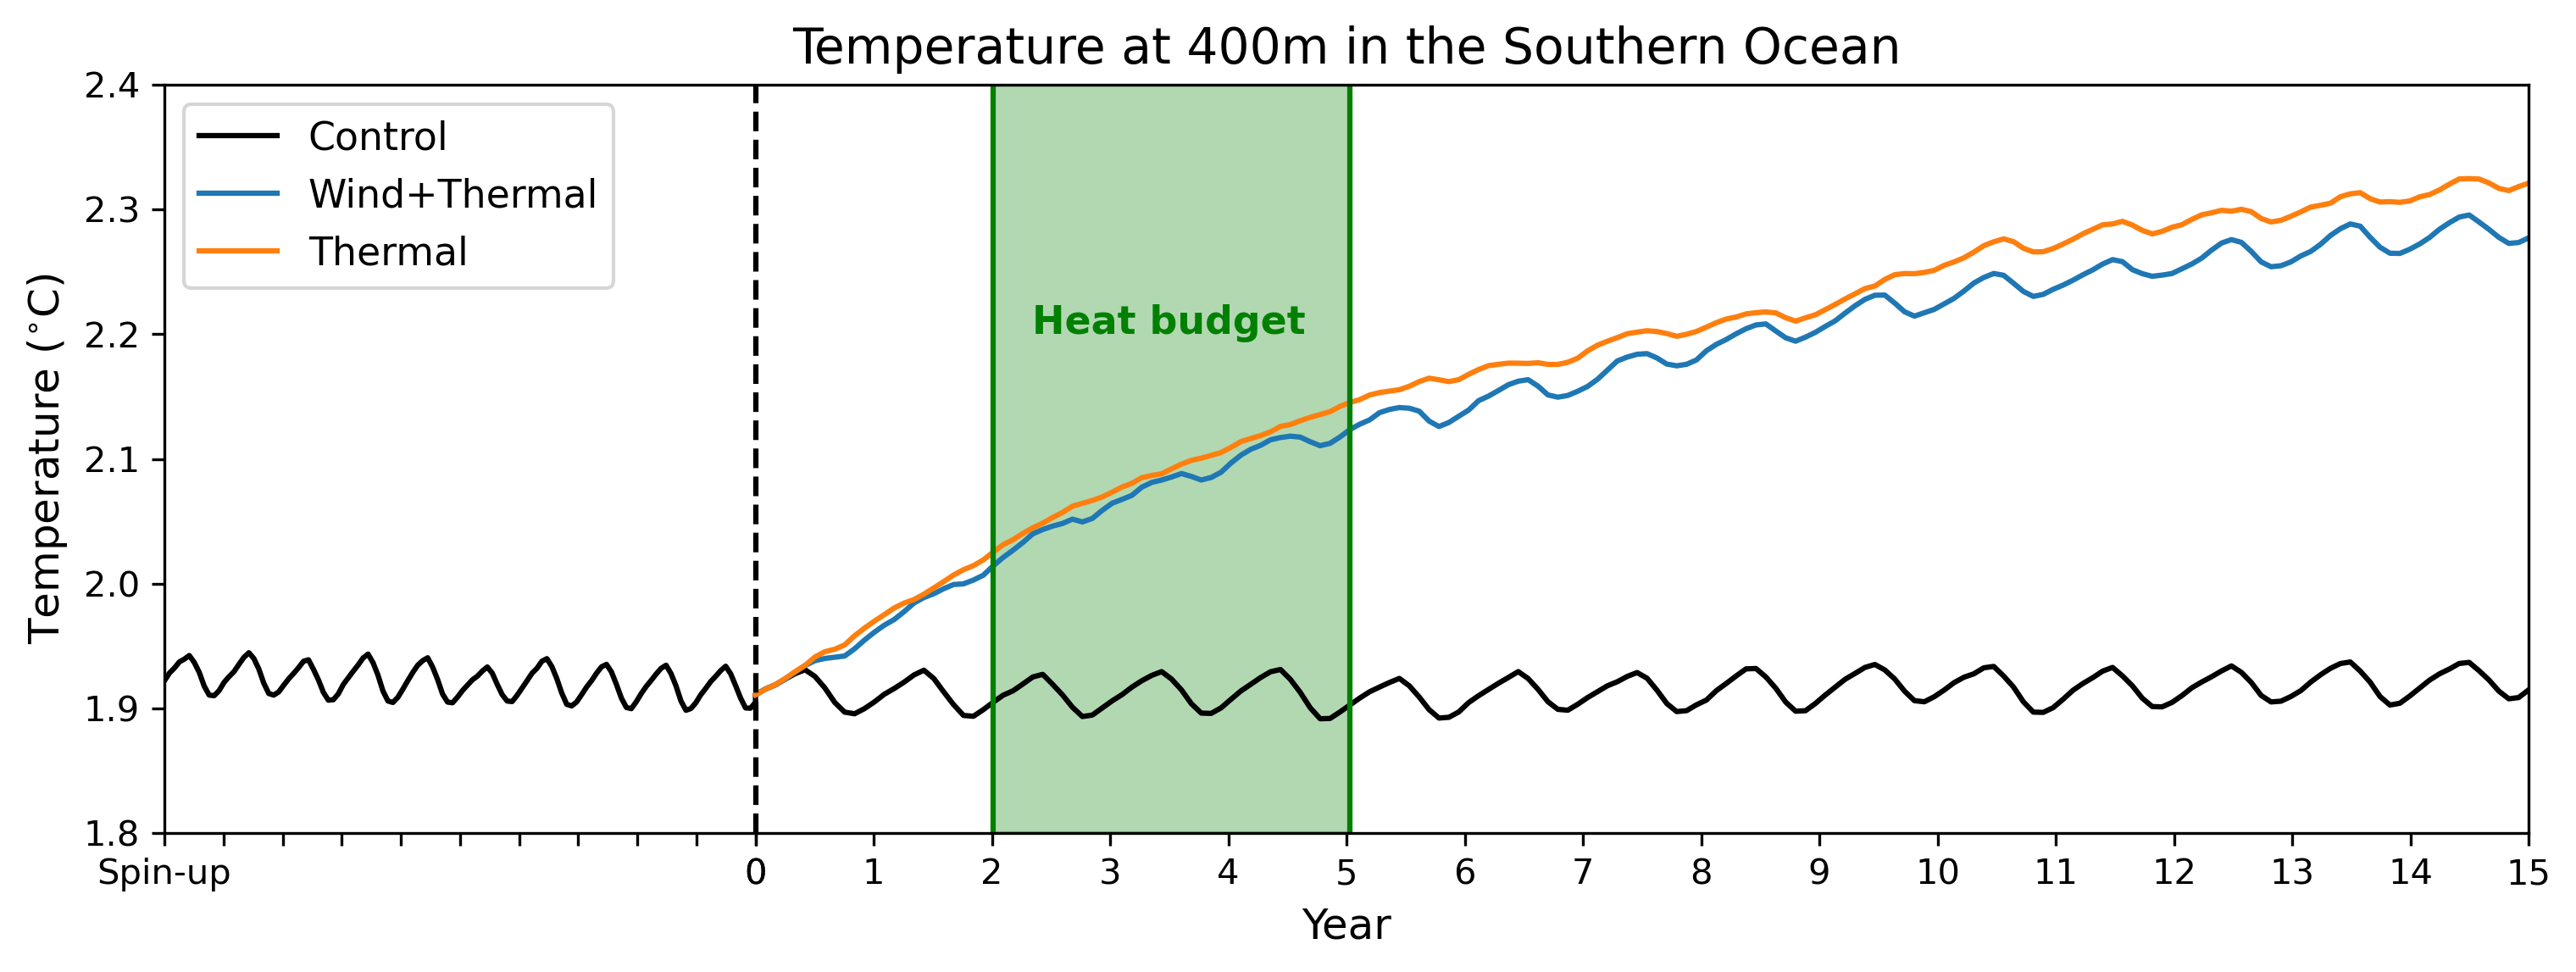

In [37]:
# for Figure 3
manual_positions = [
    (10, 100), 
    (12, 1000),
    (14,2000)
]
fig = plt.figure(figsize=(12,13),dpi = 300)
ax1 = plt.subplot(3,1,1)
ax1.plot(custom_x_ctrl,temp_400_mean_ctrl.values-273.15,linewidth = 1.5, color='k')
ax1.plot(custom_x_pert,temp_400_mean_wt.values-273.15,linewidth = 1.5)
ax1.plot(custom_x_pert,temp_400_mean_th[3:].values-273.15,linewidth = 1.5)
ax1.plot([custom_x_ctrl[120],custom_x_ctrl[120]], [1.8,2.4], linestyle='--', color='k', label='Dashed Line Data')
ax1.plot([custom_x_ctrl[144],custom_x_ctrl[144]], [1.8,2.4], linestyle='-', color='green', label='Dashed Line Data')
ax1.plot([custom_x_ctrl[180],custom_x_ctrl[180]], [1.8,2.4], linestyle='-', color='green', label='Dashed Line Data')
ax1.text(0.367,2.2,'Heat budget',fontsize = 11,color = 'g',fontweight='bold')
plt.ylim(1.8,2.4)
ax1.margins(x=0.0)  
plt.legend(['Control','Wind+Thermal','Thermal'],fontsize = 11, loc = 'upper left')
plt.ylabel('Temperature ($^{\circ}$C)', fontsize = 12)
plt.xlabel('Year', fontsize = 12)
plt.axvspan(custom_x_ctrl[144], custom_x_ctrl[180], color='green', alpha=0.3)
#ax2 = ax1.twinx()
#ax2.plot(custom_x_pert[2:],(dT_400_th[3:].values-dT_400_ctrl[120:].values),color = 'brown',linestyle='--',linewidth = 1.5)
plt.title('Temperature at 400m in the Southern Ocean', fontsize = 14)
#plt.plot([2152,2152], [2.0,2.7], linestyle='--', color='k')
#plt.plot([2154,2154], [2.0,2.7], linestyle='--', color='k')
plt.xlabel('Year', fontsize = 12)
plt.xticks(custom_ticks, custom_tick_labels)
#ax2.tick_params(axis='y', labelcolor='brown')
#ax1.text(
#        0.0, 1.08, '(a)', transform=ax1.transAxes, fontweight='bold', 
#        fontsize=13,  # Font size
#        verticalalignment='top',  # Align text vertically to the top
#        horizontalalignment='left',  # Align text horizontally to the left
#)
#plt.ylabel('temperature tendency anomaly ($^{\circ}$C/month)', fontsize = 10,color='brown')
#plt.ylim(-0.01,0.02)

Text(0, 0.5, 'Temperature anomaly ($^{\\circ}$C)')

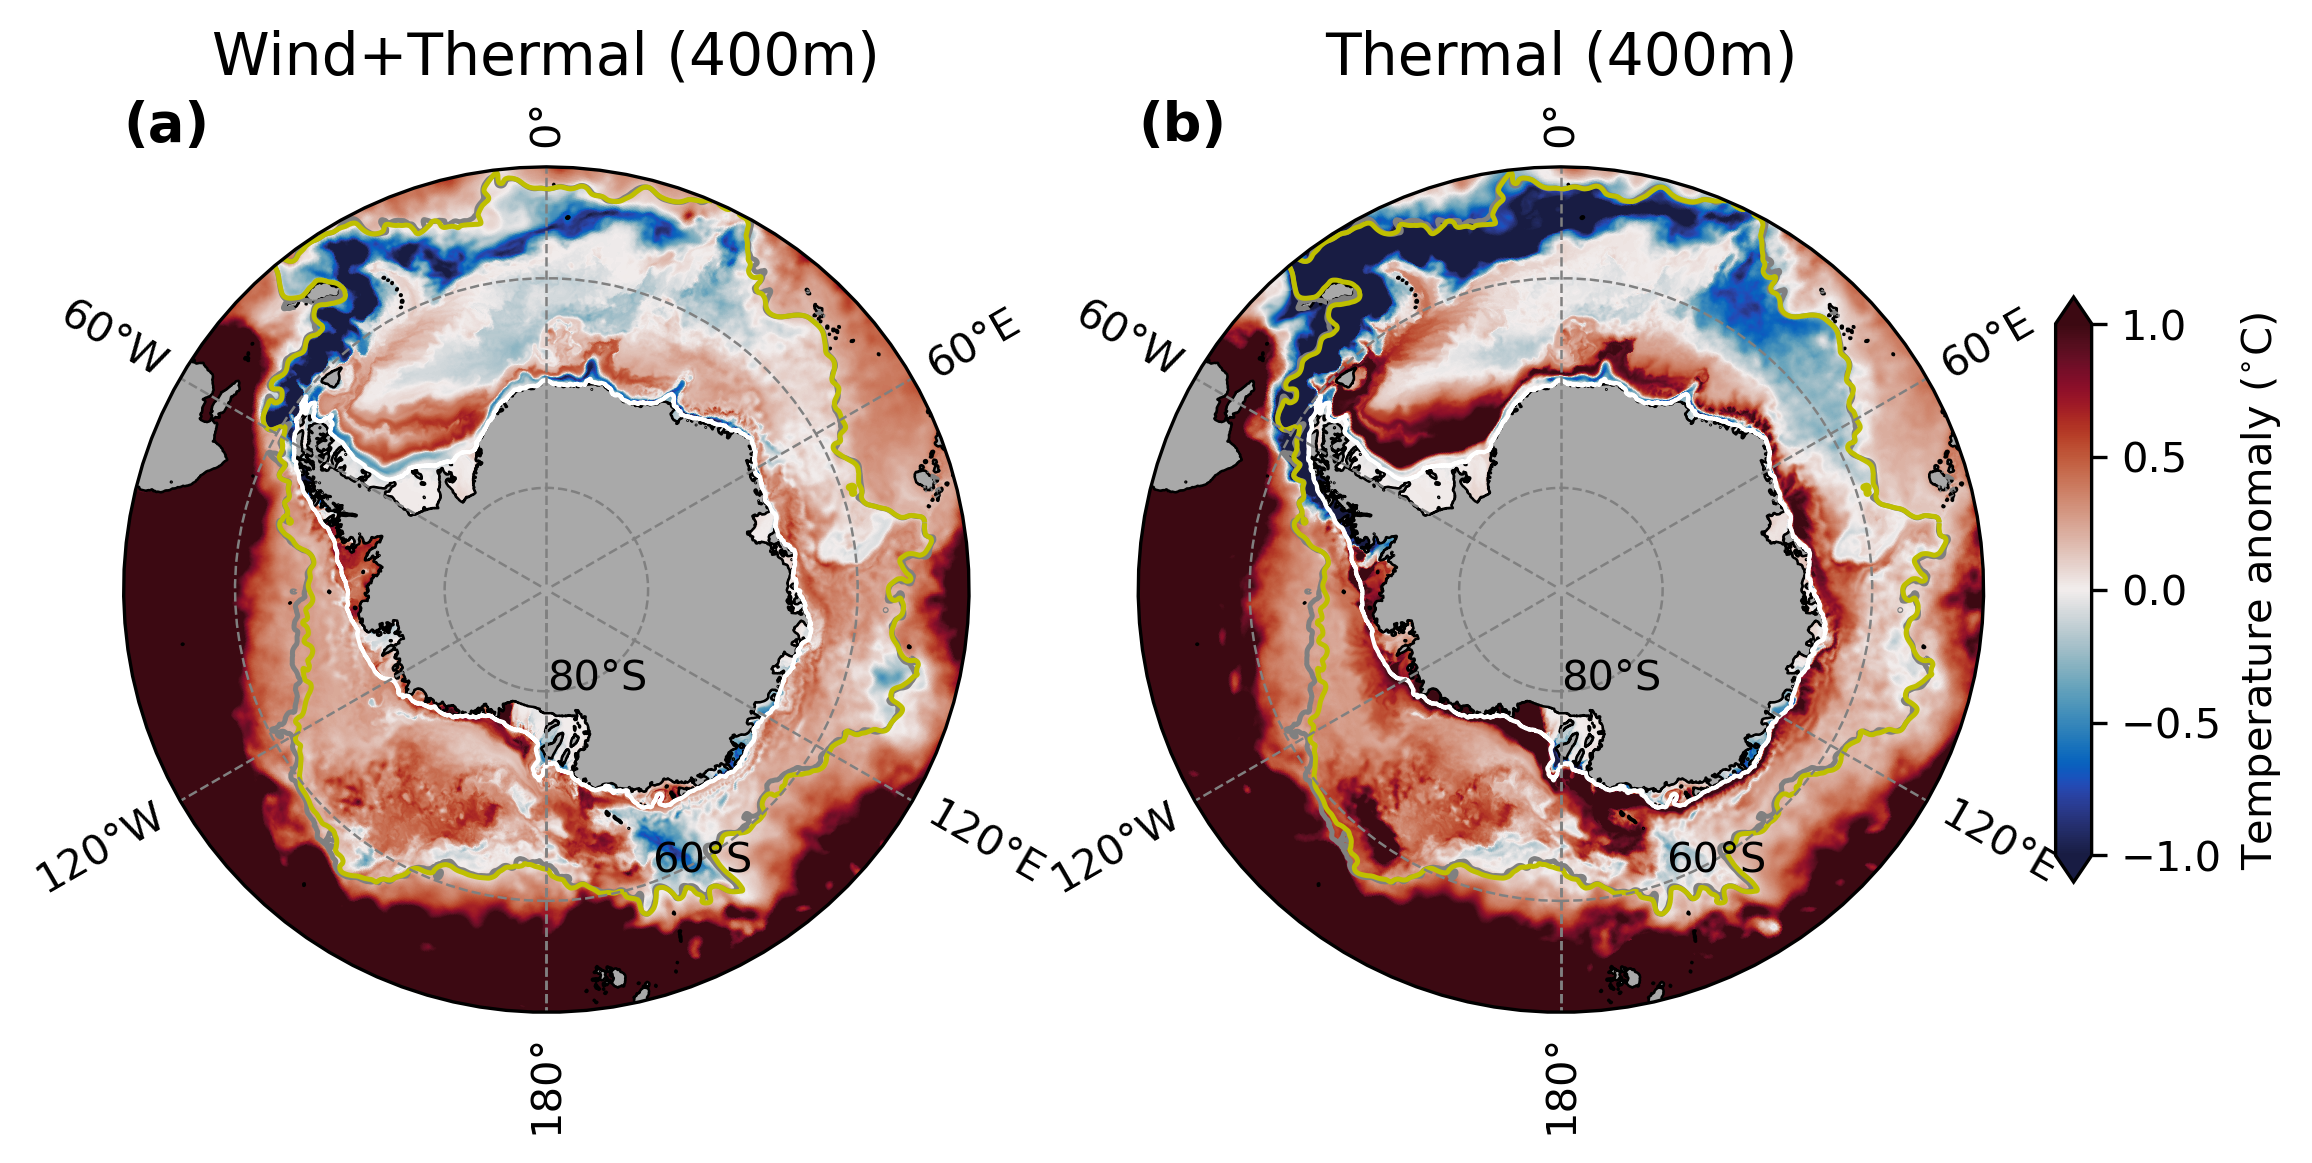

In [39]:
# For Figure 4
manual_positions = [
    (10, 100), 
    (12, 1000),
    (14,2000)
]
fig = plt.figure(figsize=(8,13),dpi = 300)
for j in range(2):
    variable_name = ['Wind+Thermal','Thermal'][j]
    order = ['(a)','(b)'][j]
    projection=ccrs.SouthPolarStereo()
    ax = plt.subplot(3,2,j+3,projection = projection,facecolor="darkgrey")
    theta = np.linspace(0,2*np.pi,100)
    center,radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)
    p2 = (data[variable_name].sel(yt_ocean = slice(-90,-50))).plot(ax=ax, vmin = -1,vmax = 1, transform=ccrs.PlateCarree(),
                              cmap=cm.cm.balance,add_colorbar = False)
    land[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=2,
                       transform=ccrs.PlateCarree(), add_colorbar=False)
    land[:,:].fillna(0).plot.contour(ax=ax, colors='k', levels=[0, 1],
                            transform=ccrs.PlateCarree(), add_colorbar=False,linewidths = 0.6)
    data['Control'].plot.contour(ax=ax, levels=[273.15+2.8], colors='grey', linewidths = 1.2,
                       transform=ccrs.PlateCarree(), add_colorbar=False)
    bound_AAIW.sel(yt_ocean = slice(-90,-50)).plot.contour(ax=ax, levels=[32.3], colors='y', linewidths = 1.2,
                       transform=ccrs.PlateCarree(), add_colorbar=False)
    ax.text(
        0.0, 1.08, f'{order}', transform=ax.transAxes, fontweight='bold', 
        fontsize=13,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
    )
    plt.plot(x_shelf, y_shelf, linewidth=1,color='white',transform=ccrs.PlateCarree())
    ax.set_title(f'{variable_name}'+' (400m)', fontsize = 14)

    #ax_cb2.yaxis.set_ticks_position('right')
    #ax_cb2.yaxis.set_label_position('right')
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        xlocs=np.arange(-180, 181, 60),
        ylocs=np.arange(-80, -49, 20),
        linewidth=0.6, linestyle='--', color='0.5', draw_labels=True
    )
# colorbar 
ax_cb2 = plt.axes([0.93, 0.42, 0.015, 0.15])
cb = plt.colorbar(p2, cax=ax_cb2,  orientation='vertical',extend='both')
cb.ax.set_ylabel('Temperature anomaly ($^{\circ}$C)', fontsize = 10)

In [48]:
mid_bound = xr.open_dataarray('/g/data/x77/hm1221/PhD_P1_data/bound_mid_mean.nc')

In [39]:
background_1 = xr.DataArray(
    data=np.ones_like(temp_ctrl_mean_new),
    coords=temp_ctrl_mean_new.coords,
    dims=temp_ctrl_mean_new.dims,
    name='ones_array'
)

Text(0, 0.5, 'Temperature anomaly ($^{\\circ}$C)')

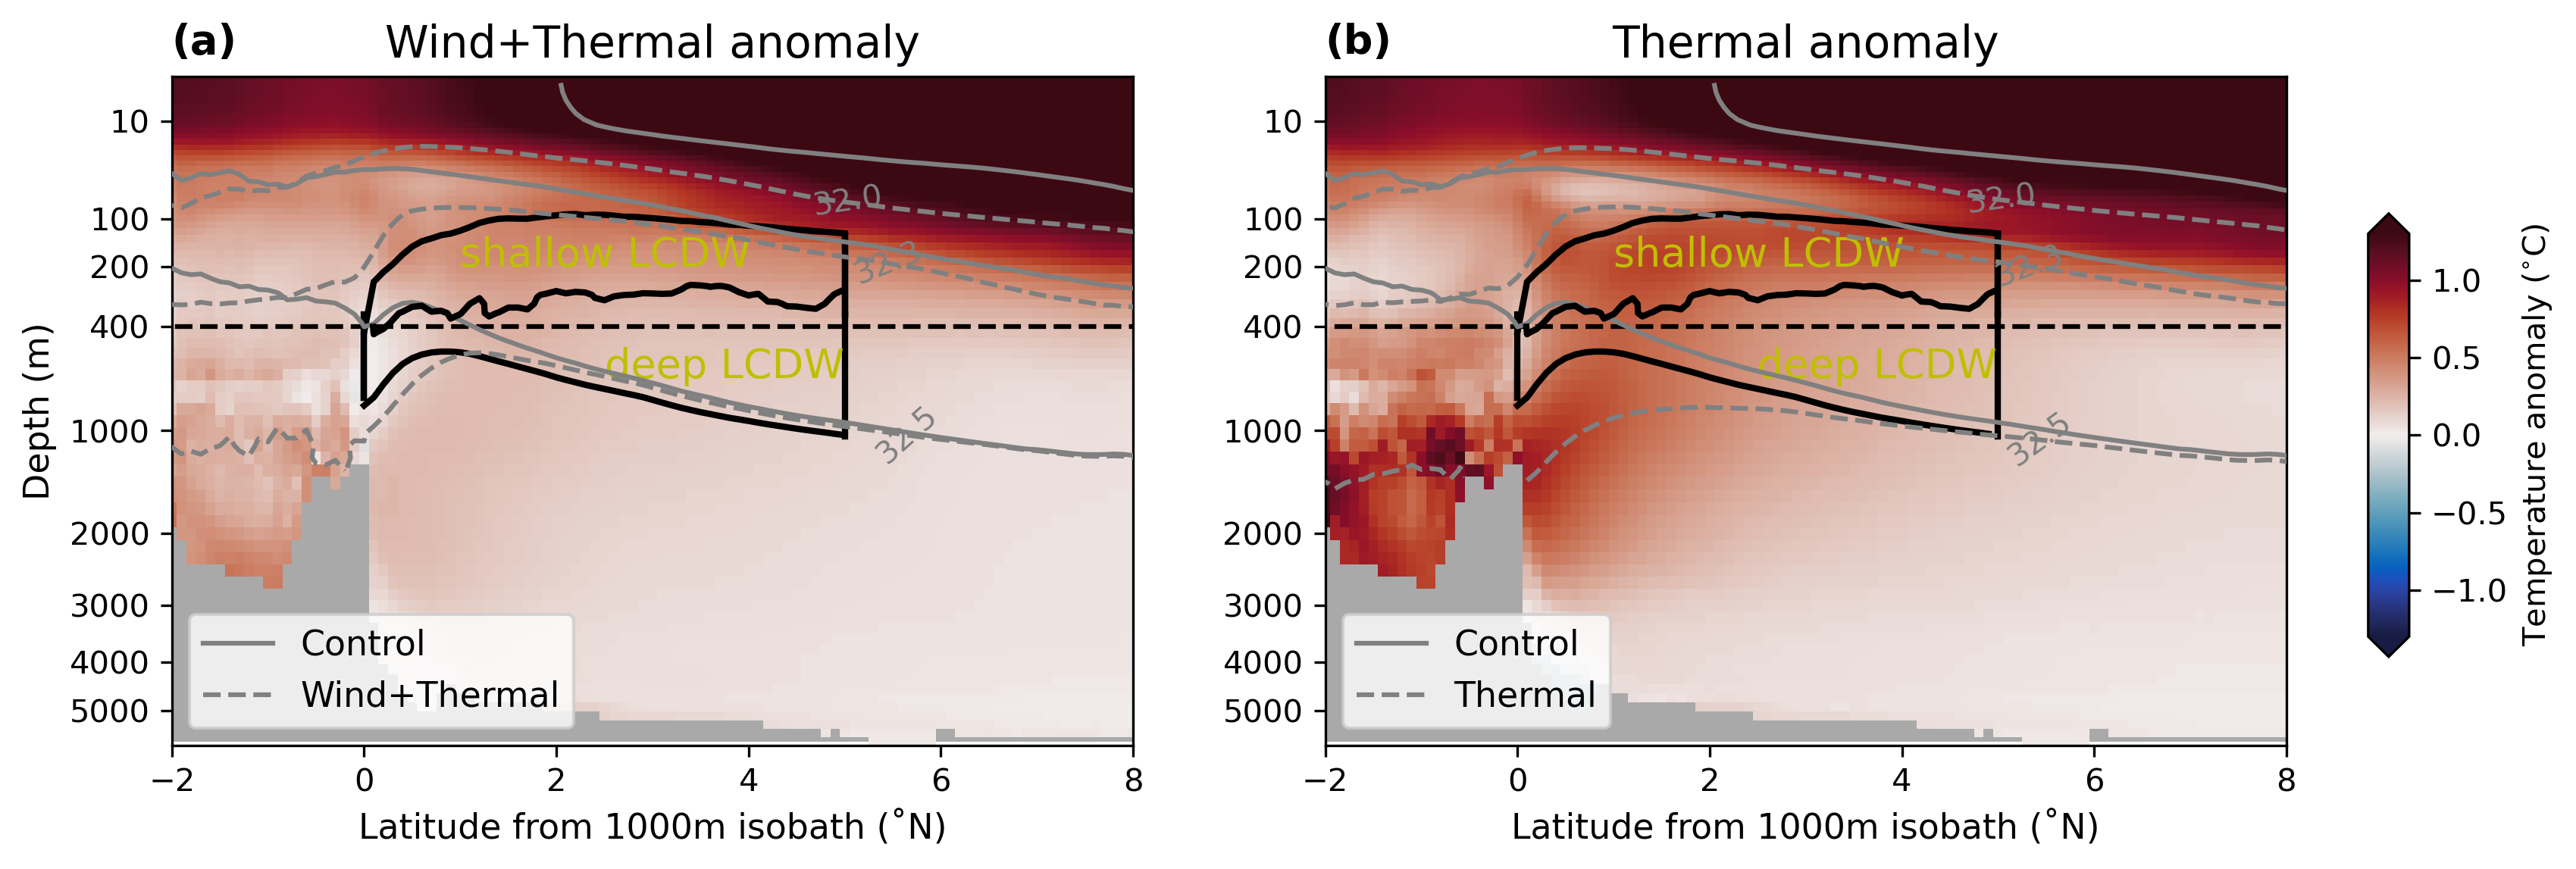

In [50]:
# For Figure 5
manual_positions = [
    (5, 100), 
    (5, 300),
    (6,1000)
]
fig = plt.figure(figsize=(12,13),dpi = 300)
# transect 
ax = plt.subplot(3,2,5)
plt.plot(0,0,color = 'grey',linestyle='-')
plt.plot(0,0,color = 'grey',linestyle='--')
plt.legend(['Control','Wind+Thermal'],
           fontsize = 11,loc = 'lower left',ncol=1)
background_1[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
p2 = (temp_wt_mean_new.sel(st_ocean = slice(1.,8000))-temp_ctrl_mean_new.sel(st_ocean = slice(1.,8000))).plot(vmin=-1.3,vmax=1.3, cmap = cm.cm.balance,add_colorbar = False)
c2 = plt.contour(rho_ctrl_mean_new.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_ctrl_mean_new.sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='grey',linestyles='-',linewidths=1.5,zorder=5)
c2 = plt.contour(rho_ctrl_mean_new.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_wt_mean_new.sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='grey',linestyles='--',linewidths=1.5,zorder=5)
plt.clabel(c2,fontsize=10,inline=False,fmt='%1.1f',levels=levs_dens,manual = manual_positions)
plt.contour(mid_bound[:41,200:251].yt_ocean_sub01.values,mid_bound[:41,200:521].st_ocean.values,mid_bound[:,200:251].sel(st_ocean = slice(0,600)),levels=[2e-9],colors='k',linestyles='-',linewidths=2,zorder=5)

plt.yticks([10.,1000,2000,3000,4000,5000], [10.,1000,2000,3000,4000,5000])  
def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.gca().invert_yaxis()
plt.xlabel('Latitude from 1000m isobath (˚N)', fontsize = 11)
plt.ylabel('Depth (m)', fontsize = 11)
plt.xlim(-2,8)
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
plt.plot([-10,20], [400,400], linestyle='--', color='k')
plt.plot(bound_up_mean[200:251].yt_ocean.values, bound_up_mean[200:251].values, c = 'k',linewidth=2)
plt.plot([5,5],[130,350], c = 'k',linewidth=2)
plt.plot([5,5],[130,350], c = 'k',linewidth=2)
#plt.plot([0,5],[350,350], c = 'k',linewidth=2)
plt.plot(bound_low_mean[200:251].yt_ocean_sub01.values, bound_low_mean[200:251].values, c = 'k',linewidth=2)
plt.plot([5,5],[350,bound_low_mean[251].values], c = 'k',linewidth=2)
plt.plot([0,0],[350,bound_low_mean[201].values], c = 'k',linewidth=2)
plt.plot([0,0],[400,bound_low_mean[201].values], c = 'k',linewidth=2)
plt.text(1,200,'shallow LCDW',fontsize = 13,color = 'y')
plt.text(2.5,650,'deep LCDW',fontsize = 13,color = 'y')
#plt.ylabel(' ', fontsize = 12)
ax.set_title('Wind+Thermal anomaly', fontsize = 14)
ax.text(
       0.0, 1.08, '(a)', transform=ax.transAxes, fontweight='bold', 
        fontsize=13,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
)
ax = plt.subplot(3,2,6)
plt.plot(0,0,color = 'grey',linestyle='-')
plt.plot(0,0,color = 'grey',linestyle='--')
plt.legend(['Control','Thermal'],
           fontsize = 11,loc = 'lower left',ncol=1)
background_1[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
p2 = (temp_th_mean_new.sel(st_ocean = slice(1.,8000))-temp_ctrl_mean_new.sel(st_ocean = slice(1.,8000))).plot(vmin=-1.3,vmax=1.3, cmap = cm.cm.balance,add_colorbar = False)
c2 = plt.contour(rho_ctrl_mean_new.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_ctrl_mean_new.sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='grey',linestyles='-',linewidths=1.5,zorder=5)
c2 = plt.contour(rho_ctrl_mean_new.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_th_mean_new.sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='grey',linestyles='--',linewidths=1.5,zorder=5)
plt.clabel(c2,fontsize=10,inline=False,fmt='%1.1f',levels=levs_dens,manual = manual_positions)
plt.contour(mid_bound[:41,200:251].yt_ocean_sub01.values,mid_bound[:41,200:521].st_ocean.values,mid_bound[:,200:251].sel(st_ocean = slice(0,600)),levels=[2e-9],colors='k',linestyles='-',linewidths=2,zorder=5)

def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.gca().invert_yaxis()
plt.xlabel('Latitude from 1000m isobath (˚N)', fontsize = 11)
plt.ylabel(' ', fontsize = 12)
plt.xlim(-2,8)
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
plt.plot([-10,20], [400,400], linestyle='--', color='k')
plt.plot(bound_up_mean[200:251].yt_ocean.values, bound_up_mean[200:251].values, c = 'k',linewidth=2)
plt.plot([5,5],[130,350], c = 'k',linewidth=2)
plt.plot([5,5],[130,350], c = 'k',linewidth=2)
#plt.plot([0,5],[350,350], c = 'k',linewidth=2)
plt.plot(bound_low_mean[200:250].yt_ocean_sub01.values, bound_low_mean[200:250].values, c = 'k',linewidth=2)
plt.plot([5,5],[350,bound_low_mean[251].values], c = 'k',linewidth=2)
plt.plot([0,0],[350,bound_low_mean[201].values], c = 'k',linewidth=2)
plt.text(1,200,'shallow LCDW',fontsize = 13,color = 'y')
plt.text(2.5,650,'deep LCDW',fontsize = 13,color = 'y')
ax.set_title('Thermal anomaly', fontsize = 14)
ax.text(
        0.0, 1.08, '(b)', transform=ax.transAxes, fontweight='bold', 
        fontsize=13,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
)
# colorbar 
ax_cb2 = plt.axes([0.93, 0.14, 0.015, 0.15])
cb = plt.colorbar(p2, cax=ax_cb2,  orientation='vertical',extend='both')
cb.ax.set_ylabel('Temperature anomaly ($^{\circ}$C)', fontsize = 10)